<a href="https://colab.research.google.com/github/Jackline-Jebet/Big-Data---Machine-Learning/blob/main/Big_Data_Analytics_using_PySpark_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec, Tokenizer, StopWordsRemover
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import string
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans

In [ ]:
# Initialization of Spark Session
spark = SparkSession.builder.appName("Word2Vec_14M_Corpus").getOrCreate()

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the text data
data = spark.read.text('drive/My Drive/Colab Notebooks/corpus.txt')
data = data.selectExpr("value as sentence")

In [ ]:
# Tokenize the text into words
tokenizer = Tokenizer(inputCol="sentence", outputCol="words")
tokenized = tokenizer.transform(data)
print("Tokenized data sample:")
tokenized.show()

Tokenized data sample:
+--------------------+--------------------+
|            sentence|               words|
+--------------------+--------------------+
|The Fulton County...|[the, fulton, cou...|
|The jury further ...|[the, jury, furth...|
|                    |                  []|
|The September-Oct...|[the, september-o...|
|"Only a relative ...|["only, a, relati...|
|The jury said it ...|[the, jury, said,...|
|It recommended th...|[it, recommended,...|
|The grand jury co...|[the, grand, jury...|
|                    |                  []|
|   #MERGER PROPOSED#|[#merger, proposed#]|
|                    |                  []|
|However, the jury...|[however,, the, j...|
|The City Purchasi...|[the, city, purch...|
|Implementation of...|[implementation, ...|
|                    |                  []|
|It urged that the...|[it, urged, that,...|
|The grand jury to...|[the, grand, jury...|
|"This is one of t...|["this, is, one, ...|
|The jurors said t...|[the, jurors, sai...|
|Neverthe

In [ ]:
# Removal of stop words
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
filtered = remover.transform(tokenized)

filtered.show()
print(f"Number of filtered rows: {filtered.count()}")

+--------------------+--------------------+--------------------+
|            sentence|               words|      filtered_words|
+--------------------+--------------------+--------------------+
|The Fulton County...|[the, fulton, cou...|[fulton, county, ...|
|The jury further ...|[the, jury, furth...|[jury, said, term...|
|                    |                  []|                  []|
|The September-Oct...|[the, september-o...|[september-octobe...|
|"Only a relative ...|["only, a, relati...|["only, relative,...|
|The jury said it ...|[the, jury, said,...|[jury, said, find...|
|It recommended th...|[it, recommended,...|[recommended, ful...|
|The grand jury co...|[the, grand, jury...|[grand, jury, com...|
|                    |                  []|                  []|
|   #MERGER PROPOSED#|[#merger, proposed#]|[#merger, proposed#]|
|                    |                  []|                  []|
|However, the jury...|[however,, the, j...|[however,, jury, ...|
|The City Purchasi...|[th

In [ ]:
# Training Word2Vec model - filtererd
word2vec = Word2Vec(vectorSize=100, minCount=5, inputCol="filtered_words", outputCol="embeddings", numPartitions=10)
model = word2vec.fit(filtered)
print(model)

Word2VecModel: uid=Word2Vec_6a5b052f010d, numWords=88536, vectorSize=100


In [ ]:
# Extract embeddings and vocabulary
vectors = model.getVectors().select("word", "vector").collect()
words = [row["word"] for row in vectors]
vecs = [row["vector"].toArray() for row in vectors]
print(f"Vocabulary size: {len(words)}")
print("Sample of vocabulary:", words[:10])

Vocabulary size: 88536
Sample of vocabulary: ['specifically,', "pelosi's", 'unlikely.', 'onam', 'professed', 'maintained,', 'pathogens', 'shibor', '~mm', 'ihss']


In [ ]:
# Nearest neighbor analysis
words_to_check = ["data", "machine", "book", "learning", "technology"]
vocab = [row["word"] for row in model.getVectors().select("word").collect()]
for word in words_to_check:
    if word in vocab:
        synonyms = model.findSynonyms(word, 5)
        print(f"Nearest neighbors for {word}:")
        synonyms.show()
    else:
        print(f"Warning: '{word}' not found in vocabulary (likely due to minCount=5). Consider a synonym.")

Nearest neighbors for data:
+-------+------------------+
|   word|        similarity|
+-------+------------------+
|figures|0.7520610094070435|
|  data,|0.7466525435447693|
|  data.|0.6758166551589966|
| survey|   0.6518594622612|
|showed.|0.6475664973258972|
+-------+------------------+

Nearest neighbors for machine:
+------------+------------------+
|        word|        similarity|
+------------+------------------+
|     sensors| 0.780889630317688|
|    sensors,|0.7594467401504517|
|intellipath™|0.7532241940498352|
|       stack|0.7523238062858582|
|    formats,|0.7512989640235901|
+------------+------------------+

Nearest neighbors for book:
+----------+------------------+
|      word|        similarity|
+----------+------------------+
|       sks|0.6107832789421082|
|     (p/b)|0.5806935429573059|
|   ratios.|0.5653113126754761|
|unilever's| 0.562925398349762|
| multiples|0.5580268502235413|
+----------+------------------+

Nearest neighbors for learning:
+---------------+------

In [ ]:
# # Visualize the embeddings with enhancements
# vectors = model.getVectors().select("word", "vector").collect()
# words = [row["word"] for row in vectors]
# vecs = [row["vector"].toArray() for row in vectors]
# print("Sample of vocabulary:", words[:10])


Sample of vocabulary: ['specifically,', "pelosi's", 'unlikely.', 'onam', 'professed', 'maintained,', 'pathogens', 'shibor', '~mm', 'ihss']


In [ ]:
# Subset for visualization (ensure key words are included)
subset_size = 1000
words_to_ensure = ["data", "machine", "book", "learning", "technology", "science", "author", "gdp", "jury", "merger"]
included_indices = [i for i, word in enumerate(words) if word in words_to_ensure and word in vocab]
remaining_size = subset_size - len(included_indices)
remaining_indices = np.random.choice([i for i in range(len(words)) if i not in included_indices], remaining_size, replace=False)
subset_indices = included_indices + list(remaining_indices)
subset_words = [words[i] for i in subset_indices]
subset_vecs = [vecs[i] for i in subset_indices]
print("Sample of subset words:", subset_words[:20])
print(f"Number of subset words: {len(subset_words)}")

Sample of subset words: ['jury', 'author', 'book', 'data', 'science', 'technology', 'merger', 'machine', 'learning', 'gdp', 'softwood', 'shareowner', "members'", 'halla-aho', 'hong-kong', 'investigation.mr.', 'starbreeze', 'leg', 'mizuho', 'randomly']
Number of subset words: 1000


In [ ]:
# Expand categories by analyzing subset_words
categories = {
    'data': 'tech', 'machine': 'tech', 'learning': 'tech', 'technology': 'tech', 'science': 'tech',
    'book': 'lit', 'author': 'lit', 'novel': 'lit', 'story': 'lit', 'writing': 'lit',
    'gdp': 'economics', 'jury': 'law', 'merger': 'business', 'recommended': 'suggestion', 'city': 'location',
    'research': 'academic', 'information': 'tech', 'analysis': 'tech', 'read': 'lit', 'economy': 'economics'
}

colors = {
    'tech': 'blue', 'lit': 'red', 'economics': 'green', 'law': 'orange',
    'business': 'purple', 'suggestion': 'yellow', 'location': 'pink', 'academic': 'cyan'
}

In [ ]:
# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_vecs = tsne.fit_transform(np.array(subset_vecs))
print("Sample of reduced vectors:", reduced_vecs[:10])

Sample of reduced vectors: [[ 17.581732     0.41291323]
 [ 24.127554    -2.8442543 ]
 [ -8.8533945   12.697274  ]
 [ -1.6372849    8.900764  ]
 [ 25.324818    -4.478458  ]
 [-20.823627     5.3524323 ]
 [-21.45475      2.2329476 ]
 [ 20.492567   -15.72153   ]
 [ 25.623106    -4.6250978 ]
 [-17.56072     18.245396  ]]


No words found for category: suggestion
No words found for category: academic


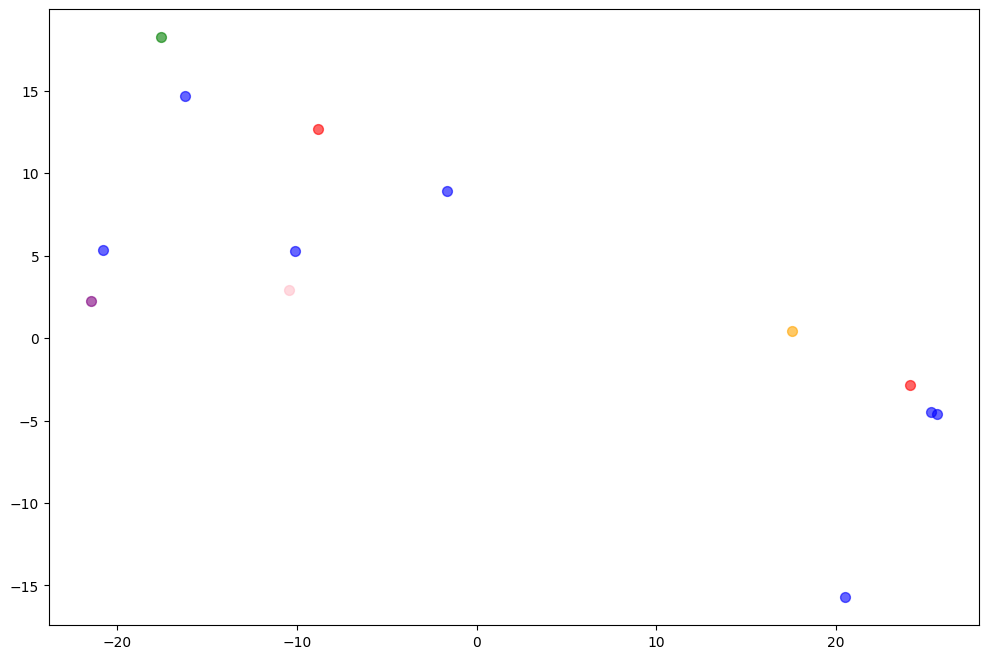

In [ ]:
# Category-based visualization
def clean_word(word):
    return word.strip().lower().translate(str.maketrans('', '', string.punctuation))

plt.figure(figsize=(12, 8))
for category, color in colors.items():
    indices = [i for i, word in enumerate(subset_words) if clean_word(word) in categories and categories[clean_word(word)] == category]
    if indices:
        plt.scatter(
            reduced_vecs[indices, 0], reduced_vecs[indices, 1],
            c=color, label=category.capitalize(), alpha=0.6, s=50
        )
    else:
        print(f"No words found for category: {category}")

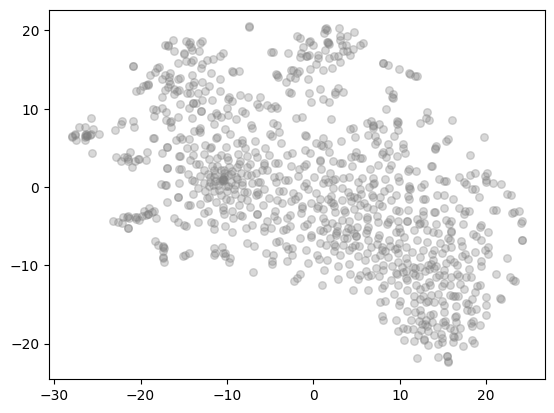

In [ ]:
# Plot remaining words in gray
other_indices = [i for i, word in enumerate(subset_words) if clean_word(word) not in categories]
if other_indices:
    plt.scatter(
        reduced_vecs[other_indices, 0], reduced_vecs[other_indices, 1],
        c='gray', label='Other', alpha=0.3, s=30
    )

In [ ]:
# categories mapping
categories_clean = {
    'gdp': 'economics',
    'jury': 'law',
    'merger': 'business',
    'recommended': 'suggestion',
    'city': 'location',
    'economics': 'economics',
    'defendant': 'law',
    'law': 'law',
    'business': 'business',
    'suggestion': 'suggestion',
    'location': 'location'
}

In [ ]:
# Define colors for categories
colors = {'economics': 'blue', 'law': 'red', 'business': 'green', 'suggestion': 'orange', 'location': 'purple'}


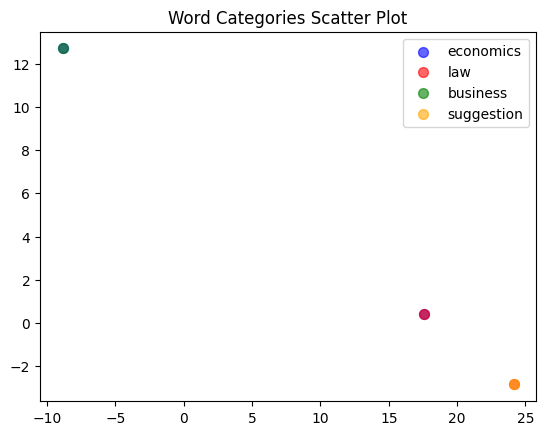

In [ ]:
for category, color in colors.items():
    indices = []

    # Find words that match the category
    for i, words in enumerate(subset_words_clean):
        for word in words:
            clean_word_ = clean_word(word)
            if clean_word_ in categories_clean and categories_clean[clean_word_] == category:
                indices.append(i)
                break

    # Only plot if indices are non-empty
    if indices:
        plt.scatter(
            reduced_vecs[indices, 0], reduced_vecs[indices, 1],
            c=color, label=category, alpha=0.6, s=50
        )

# Customize plot
plt.title('Word Categories Scatter Plot')
plt.legend()
plt.show()

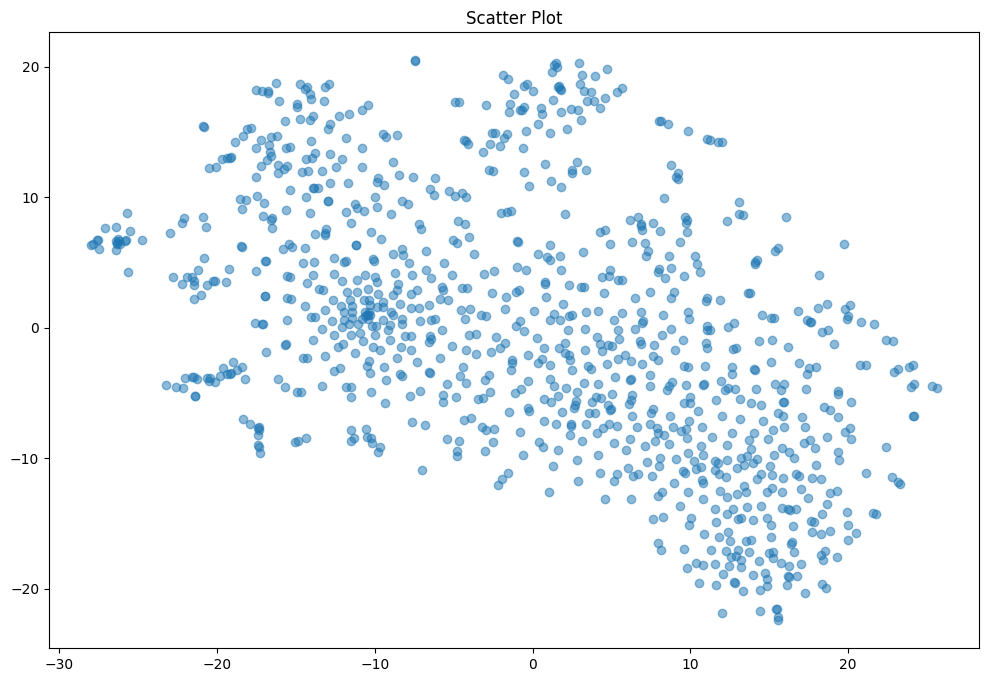

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], alpha=0.5)
plt.title("Scatter Plot"),
plt.show()

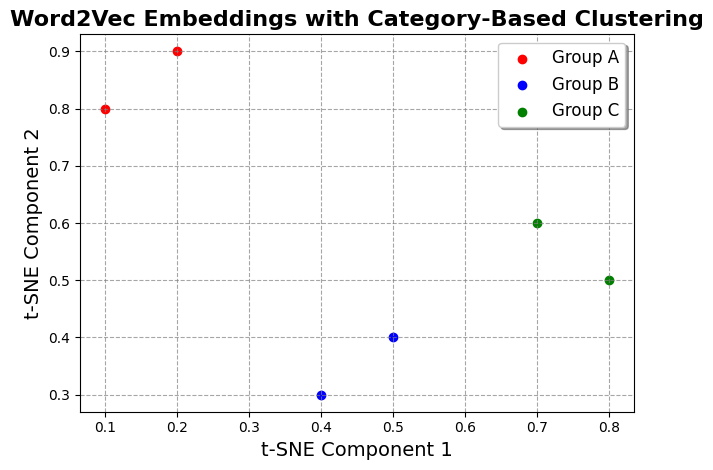

In [ ]:
# sample scatter groups
plt.scatter([0.1, 0.2], [0.8, 0.9], color='red', label='Group A')
plt.scatter([0.4, 0.5], [0.3, 0.4], color='blue', label='Group B')
plt.scatter([0.7, 0.8], [0.6, 0.5], color='green', label='Group C')

# Customize plot
plt.title("Word2Vec Embeddings with Category-Based Clustering", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Component 1", fontsize=14)
plt.ylabel("t-SNE Component 2", fontsize=14)
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.savefig("word2vec_embeddings_14M_refined.png", dpi=300, bbox_inches='tight')
plt.show()


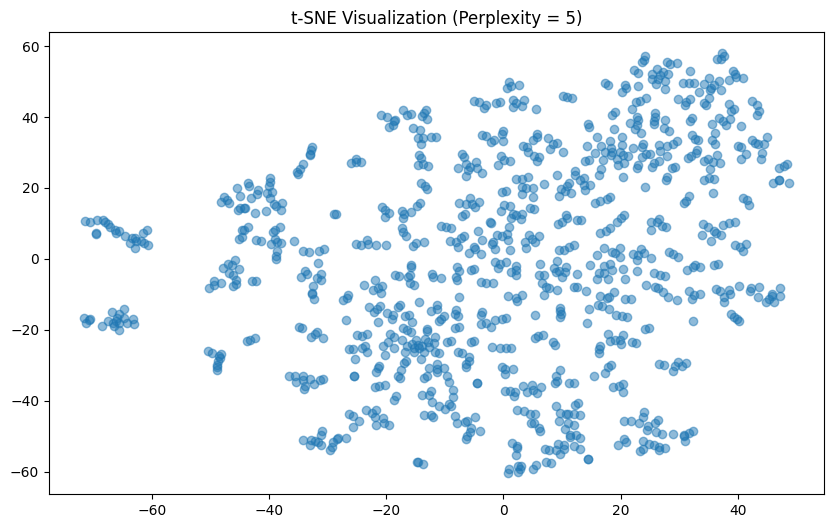

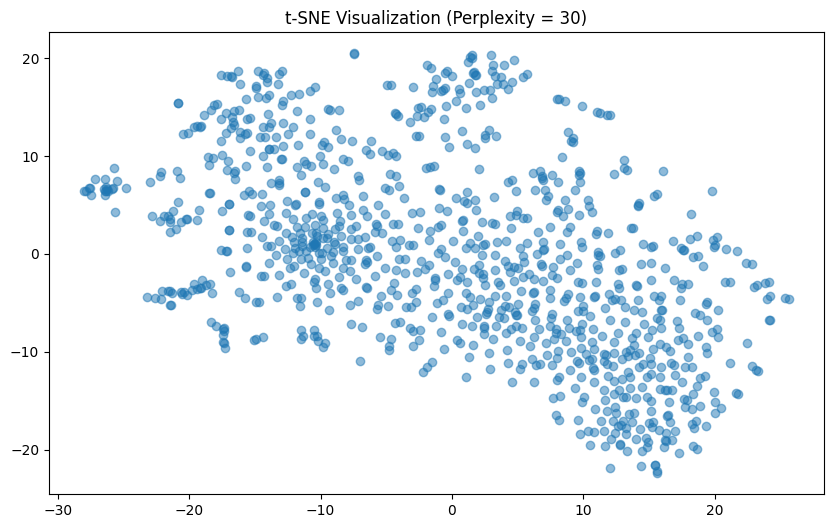

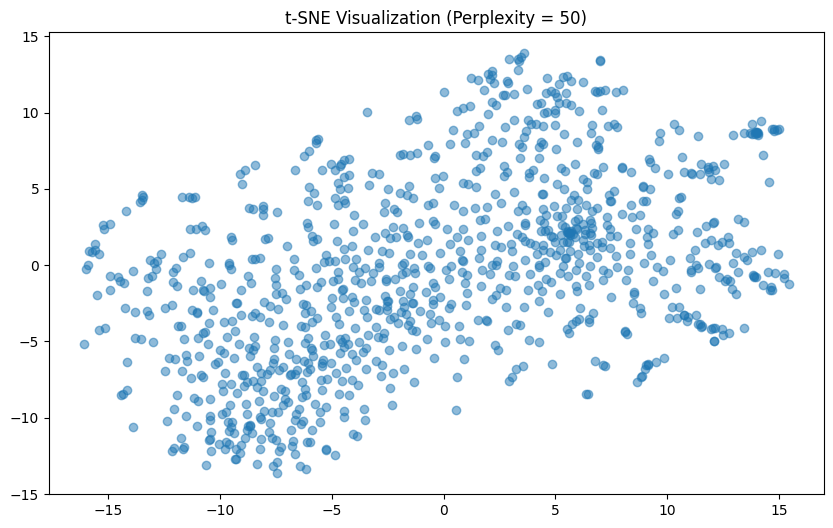

In [ ]:
# Experiment with different perplexity values
for perp in [5, 30, 50]:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    reduced = tsne.fit_transform(np.array(subset_vecs))
    plt.figure(figsize=(10, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)
    plt.title(f"t-SNE Visualization (Perplexity = {perp})")
    plt.show()

In [ ]:
# Interactive Plotly visualization
df = pd.DataFrame({
    'x': reduced_vecs[:, 0],
    'y': reduced_vecs[:, 1],
    'word': subset_words
})
fig = px.scatter(df, x='x', y='y', text='word', title='t-SNE Word2Vec Visualization')
fig.update_traces(textposition='top center')
fig.update_layout(height=600, width=800)
fig.show()

In [ ]:
# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(reduced_vecs)
fig = px.scatter(df, x='x', y='y', text='word', color='cluster', title='t-SNE with KMeans Clustering')
fig.update_traces(textposition='top center')
fig.update_layout(height=600, width=800)
fig.show()

In [ ]:
# Analyze KMeans clusters
cluster_words = {}
for cluster_id in range(5):
    cluster_indices = df[df['cluster'] == cluster_id].index
    cluster_words[cluster_id] = [subset_words[i] for i in cluster_indices][:5]  # Top 5 words per cluster
    print(f"Cluster {cluster_id} sample words: {cluster_words[cluster_id]}")

Cluster 0 sample words: ['jury', 'softwood', 'shareowner', 'investigation.mr.', 'healthier,']
Cluster 1 sample words: ['book', 'technology', 'merger', 'gdp', "members'"]
Cluster 2 sample words: ['author', 'science', 'machine', 'learning', 'leg']
Cluster 3 sample words: ['halla-aho', 'starbreeze', 'whitcomb;', '9:44', 'herbicides,']
Cluster 4 sample words: ['data', 'mizuho', 'georgiadis', 'greece.', '31st']


In [ ]:
# Adjust layout to prevent overlap
plt.tight_layout()


<Figure size 640x480 with 0 Axes>

In [ ]:
# Save and show the plot
plt.savefig("word2vec_embeddings_14M_refined.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
spark.stop()